## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

##### I identified 207 missing values in the total_bedrooms column. Since each row in this dataset represents a neighborhood rather than a single house, these missing values signify errors or omissions, not a literal zero (a neighborhood of only studios). Replacing these missing values with 0 is dangerous because the model will learn incorrect patterns, such as a large population living with no bedrooms. Because 207 represents a small percentage of our dataset, the first approach that comes to mind is to impute the missing values using the median of the total_bedrooms column.

In [3]:
df_problematic = df[df['total_bedrooms'].isnull()]

df_problematic.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY


In [4]:
df_problematic.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,207.000000,207.000000,207.000000,207.000000,0.0,207.000000,207.000000,207.000000,207.000000
mean,-119.472560,35.497633,29.270531,2562.603865,NaN,1477.772947,510.024155,3.822244,206007.280193
std,2.001424,2.097298,11.964927,1787.269789,NaN,1057.448212,386.120704,1.955595,111638.214545
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.810000,33.970000,19.000000,1307.500000,NaN,781.000000,258.000000,2.564150,128750.000000
50%,-118.490000,34.200000,30.000000,2155.000000,NaN,1217.000000,427.000000,3.411500,175000.000000
75%,-117.985000,37.495000,38.000000,3465.000000,NaN,1889.500000,628.000000,4.615750,267700.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


##### After analyzing the problematic rows, I observed that the other columns have normal values compared to the rest of the dataset. I based my decision on the median house value, the difference is insignificant, suggesting that the missing values are likely the result of a data collection mistake. Because the number of missing values is small(5%), the missing values are completly random ,probably a mistake in data collection ,and is a numeric type I will use the median value of total_bedrooms to fill in the missing values. This approach is preferable to dropping rows, as it preserves the dataset's size and avoids potential bias from removing data points.

In [5]:
median_number_of_bedrooms = df['total_bedrooms'].median()
df_cleaned = df.fillna({'total_bedrooms': median_number_of_bedrooms})

In [6]:
df_cleaned.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [7]:
df_cleaned.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


##### Now that the dataset is "cleaned", I will continue with the analysis. At first I will explore some vizualizations and relations using the "explore-pricing.py" script.

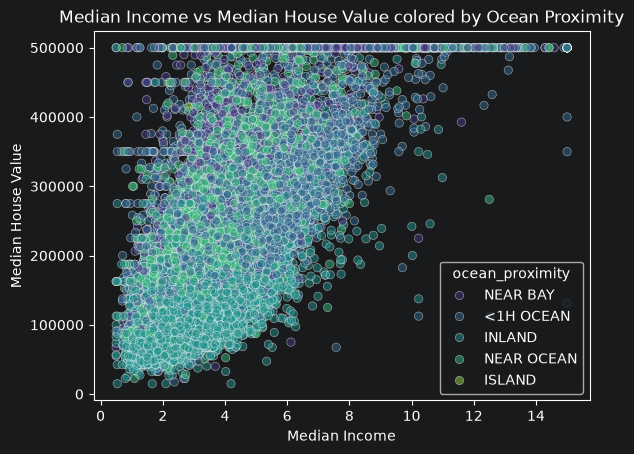

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='median_income', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Median Income vs Median House Value colored by Ocean Proximity')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

##### I consider this scatter plot to be very relevant because it shows a clear positive correlation between median income and median house value. The diagram shows that as median income increases, the median house value also tends to increase. Additionally, the color coding by ocean proximity reveals that neighborhoods closer to the ocean tend to have higher house values, which is an important insight for our regression model. This suggests that both median income and ocean proximity are significant factors in determining house prices in this dataset.

In [4]:
df_cleaned['rooms_per_household'] = df_cleaned['total_rooms'] / df_cleaned['households']
df_cleaned.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853


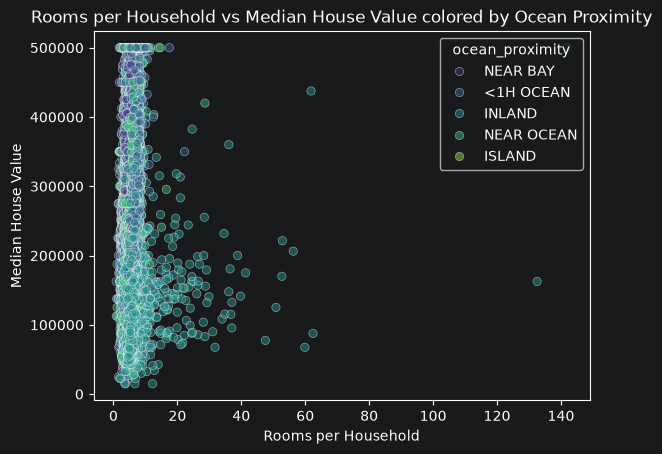

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='rooms_per_household', y='median_house_value', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Rooms per Household vs Median House Value colored by Ocean Proximity')
plt.xlabel('Rooms per Household')
plt.ylabel('Median House Value')
plt.show()

##### The scatter plot of rooms per household versus median house value, colored by ocean proximity is not as relevant as the previous one. The relationship between rooms per household and median house value is not as clear or strong as the relationship between median income and median house value. While there may be some correlation, it is not as pronounced, and the data points are more scattered. Additionally, the color coding by ocean proximity does not reveal a significant pattern in this case. Therefore, I would consider this scatter plot to be less relevant for our regression model compared to the previous one.


C:\Users\NeagVasileDragos\AppData\Local\Temp\ipykernel_18452\3358665981.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


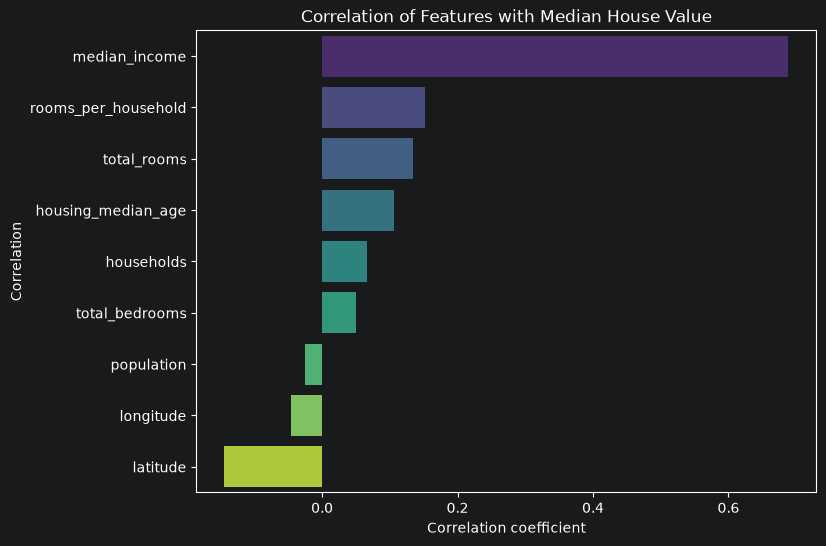

In [15]:
corr = df_cleaned.corr(numeric_only=True)

price_corr = corr['median_house_value'].sort_values(ascending=False)

price_corr = price_corr.drop('median_house_value')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Median House Value')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.xlabel('Correlation coefficient')
plt.show()

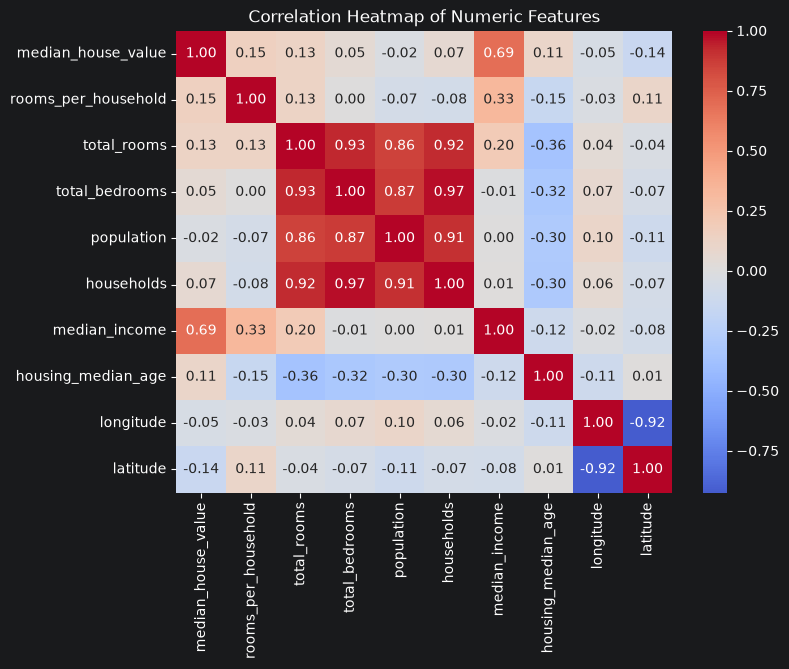

In [18]:
numeric_cols = ['median_house_value', 'rooms_per_household', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income','housing_median_age', 'longitude', 'latitude']

plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### The heatmap diagram shows the correlation between different features and median house value. The features with the highest positive correlation with median house value are median income, rooms per household, and total rooms. This suggests that neighborhoods with higher median incomes, more rooms per household, and more total rooms tend to have higher house values. On the other hand, features like population and households show a negative correlation with median house value, indicating that neighborhoods with larger populations and more households tend to have lower house values. Overall, this heatmap provides valuable insights into the relationships between different features and median house value, which can inform our future model.

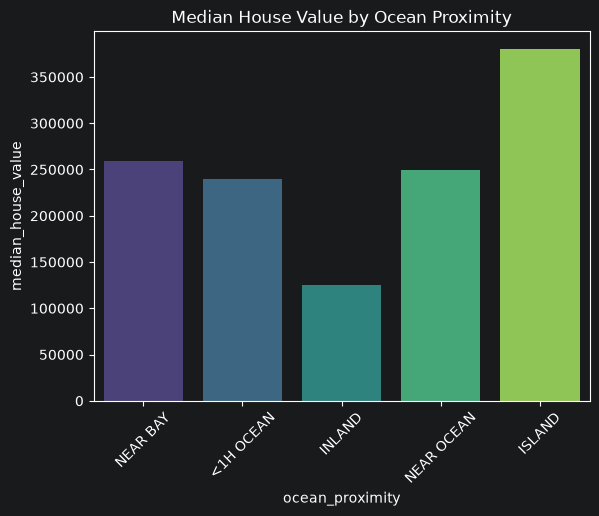

In [20]:


sns.barplot(x='ocean_proximity', y='median_house_value', data=df_cleaned, hue='ocean_proximity',
    palette='viridis',
    errorbar=None,
    legend=False )
plt.title('Median House Value by Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

##### The diagram shows that the median house value varies significantly based on ocean proximity. Island neighborhoods have the highest median house values, followed by neighborhoods that are near the ocean and the bay. In contrast, neighborhoods that are inland have lower median house values. This suggests that ocean proximity is an important factor in determining house prices in this dataset.

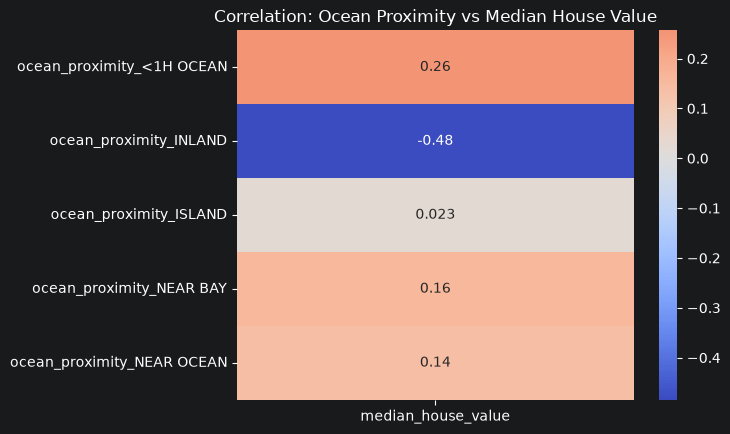

In [22]:

df_encoded_ocean = pd.get_dummies(df_cleaned[['ocean_proximity', 'median_house_value']], drop_first=False)

corr_ocean = df_encoded_ocean.corr()

corr_with_price = corr_ocean[['median_house_value']].drop('median_house_value')

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Ocean Proximity vs Median House Value')
plt.show()

##### The heatmap shows the correlation between ocean proximity and median house value. The diagram indicates how the value evolves based on the proximity to the ocean. The correlation values suggest that neighborhoods that are closer to the ocean tend to have higher median house values, while those that are inland have lower median house values. This reinforces the earlier observation that ocean proximity is a significant factor in determining house prices in this dataset.

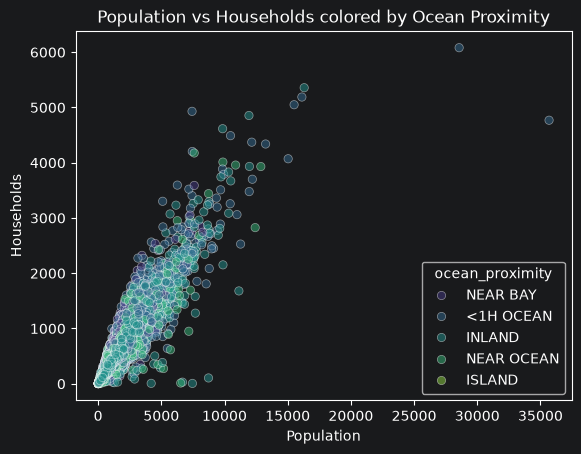

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='population', y='households', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Population vs Households colored by Ocean Proximity')
plt.xlabel('Population')
plt.ylabel('Households')
plt.show()

##### The diagram shows the relationship between population and households colored by ocean proximity. The plot indicates that if the population increases in neighborhood , the number of households also tends to increase, which is expected. The color coding by ocean proximity does not reveal a significant pattern in this case. Overall, this scatter plot provides insights into the relationship between population and households, but it may not be as relevant for our regression model compared to other features.

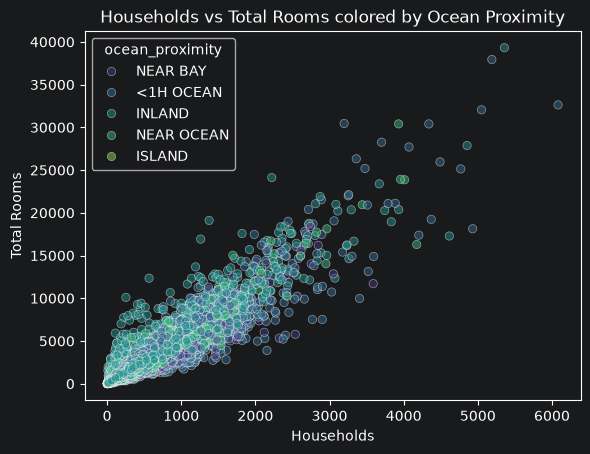

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x='households', y='total_rooms', data=df_cleaned, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Households vs Total Rooms colored by Ocean Proximity')
plt.xlabel('Households')
plt.ylabel('Total Rooms')
plt.show()

##### The diagram shows the relationship between households and total rooms colored by ocean proximity. The plot indicates that as the number of households increases, the total number of rooms also tends to increase. The same scenario is observed in the previous diagram.

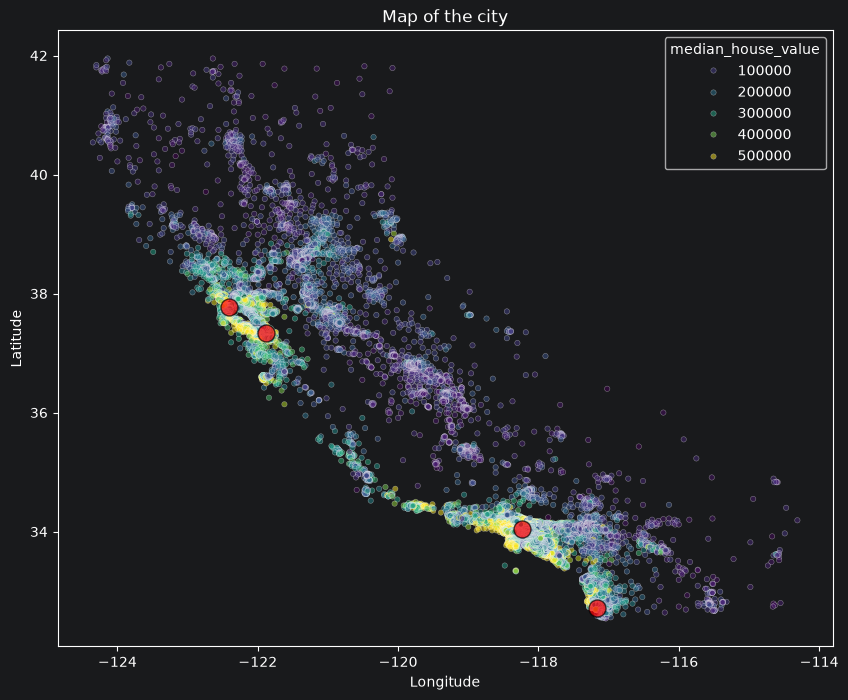

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', data=df_cleaned, alpha=0.5, hue='median_house_value', palette='viridis', s=15)
big_cities = {
    'Los Angeles': (-118.24, 34.05),
    'San Francisco': (-122.41, 37.77),
    'San Diego': (-117.16, 32.71),
    'San Jose': (-121.88, 37.33)
}

for city, (lon, lat) in big_cities.items():
    plt.scatter(lon, lat, color='red',s=150,edgecolors='black', label=city, alpha=0.7)

plt.title('Map of the city')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

##### This diagram shows the geographical distribution of neighborhoods based on their latitude and longitude colored by median house value. The plot shows the big cities nearby the neighborhoods, which are Los Angeles, San Francisco and San Diego (the big red dots on the map). From what I can see, in the proximity of the big cities around the ocean , prices tend to be higher but I have to do a more detalied analysis to confirm this. Overall, this scatter plot provides insights into the geographical distribution of neighborhoods and their median house values, which can inform our future model. And we can see that there are more neighborhoods in the proximity of the big cities.

In [14]:
import numpy as np
distances = pd.DataFrame({
    'Los Angeles': np.sqrt((df_cleaned['longitude'] - -118.24)**2 + (df_cleaned['latitude'] - 34.05)**2),
    'San Francisco': np.sqrt((df_cleaned['longitude'] - -122.41)**2 + (df_cleaned['latitude'] - 37.77)**2),
    'San Diego': np.sqrt((df_cleaned['longitude'] - -117.16)**2 + (df_cleaned['latitude'] - 32.71)**2),
    'San Jose': np.sqrt((df_cleaned['longitude'] - -121.88)**2 + (df_cleaned['latitude'] - 37.33)**2)
    # Here I used the basic distance fromula to calculate the distance from the neighborhoods to big cities even if it's not the best approach because the earth is not flat but for this analysis I think it's enough
})

df_cleaned['closest_cities']= distances.idxmin(axis=1)


In [15]:
df_cleaned

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,closest_cities
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,San Francisco
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,San Francisco
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,San Francisco
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,San Francisco
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,San Francisco
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,San Francisco
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,San Francisco
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,San Francisco
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,San Francisco


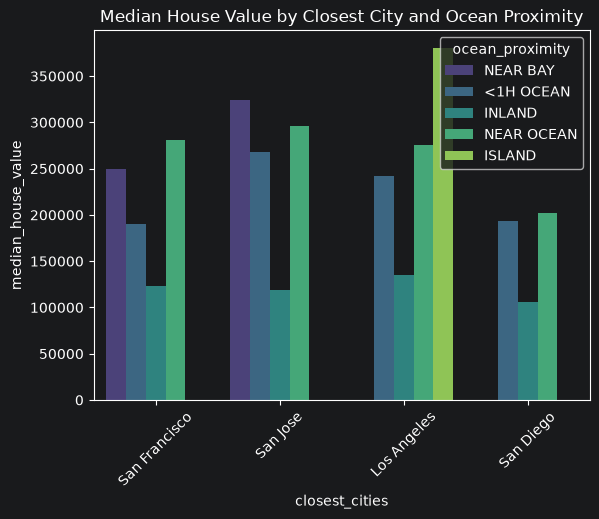

In [17]:


sns.barplot(x='closest_cities', y='median_house_value', data=df_cleaned, hue='ocean_proximity',
    palette='viridis',
    errorbar=None,
    legend=True )
plt.title('Median House Value by Closest City and Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

##### As we can see in diagram , the median house value varies based on the closest city and ocean proximity. In my opinion the closest city is a relevant factor in determining house prices , especially when combined with the ocean proximity.

In [19]:
bins=[0, 10, 20 ,30, 40, df_cleaned['housing_median_age'].max()]
labels=['Very new','New','Medium','Old','Very Old']

df_cleaned['age_bin']=pd.cut(df_cleaned['housing_median_age'], bins=bins, labels=labels, include_lowest=True)

print(df_cleaned[['housing_median_age','age_bin']].head(10), df_cleaned['age_bin'].value_counts())

   housing_median_age   age_bin
0                41.0  Very Old
1                21.0    Medium
2                52.0  Very Old
3                52.0  Very Old
4                52.0  Very Old
5                52.0  Very Old
6                52.0  Very Old
7                52.0  Very Old
8                42.0  Very Old
9                52.0  Very Old age_bin
Old         5617
Medium      4852
New         4724
Very Old    3878
Very new    1569
Name: count, dtype: int64


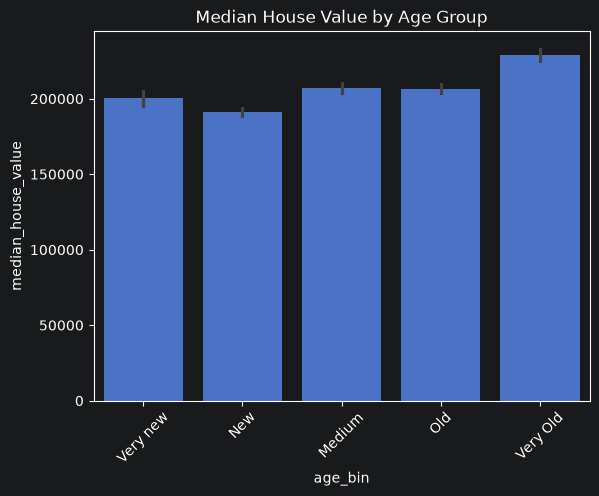

In [20]:
sns.barplot(x='age_bin', y='median_house_value', data=df_cleaned)
plt.title('Median House Value by Age Group')
plt.xticks(rotation=45)
plt.show()

##### Looking at the diagram, we can see that the age group of the houses is not as relevant  as I thought . The very old group of houses has the highest median house value fact that indicates that maybe old houses have a really good location , fact that should be analyzed